In [1]:
import gdsfactory as gf
from gsim.palace import DrivenSim
from ihp import PDK

PDK.activate()

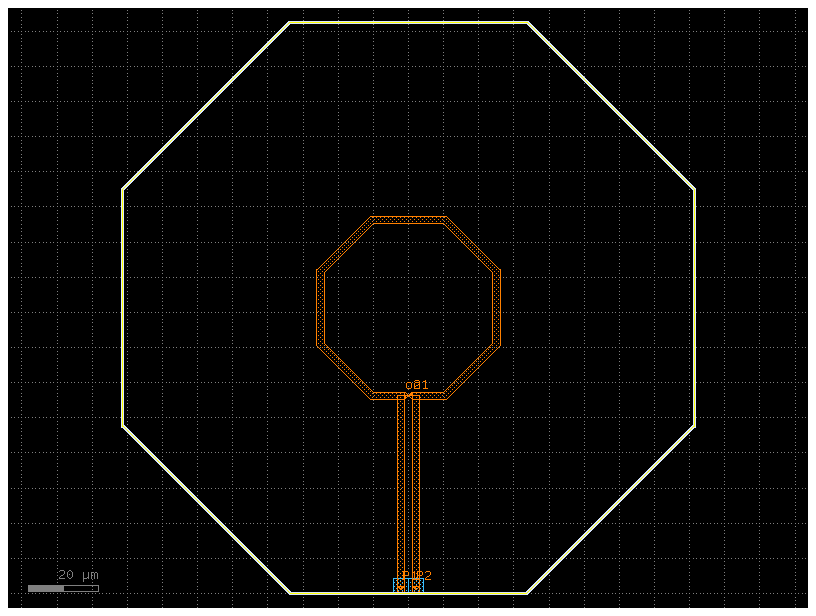

In [2]:
c = gf.components.inductor(
    width=2, 
    space=2.1, 
    diameter=50,
    resistance=0.578, 
    inductance=500e-12, 
    turns=1,
    layer_metal='TopMetal2drawing',
    layer_inductor='INDdrawing',
    layer_metal_pin='TopMetal2drawing',
    layers_no_fill=('NoMetFillerdrawing',)
).copy()

# Add patches around the inductor ports
s = 2.1  
patch_size = s * 2  #to ensure overlap

for port_name in ["P1", "P2"]:
    port = c.ports[port_name]
    cx, cy = port.center
    patch = gf.components.rectangle(
        size=(patch_size, patch_size),
        layer='Metal1drawing',
        centered=True,
    )

    c.add_ref(patch).move((cx, cy))

cc = c.copy()
cc.flatten()

c.draw_ports()
c.plot()

In [3]:
sim = DrivenSim()
sim.set_output_dir("runs/palace-sim-inductor-smallground")
sim.set_geometry(cc)

sim.set_stack(
    substrate_thickness=200.0,
    air_above=50.0,
    include_substrate=True
)

# o1 and o2 are gap ports (open loop ends) — not physical terminals
#sim.add_port("P1", layer="topmetal2", geometry="inplane",excited=True,offset=-2.0)
#sim.add_port("P2", layer="topmetal2", geometry="inplane",excited=True,offset=-2.0)
sim.add_port("P1", from_layer="metal1", to_layer="topmetal2", geometry="via", excited=True)
sim.add_port("P2", from_layer="metal1", to_layer="topmetal2", geometry="via", excited=True)

sim.set_driven(fmin=1e9, fmax=150e9, num_points=50)

print(sim.validate_config())

Validation: PASSED


In [4]:
sim.mesh(preset="graded",margin=50, refined_mesh_size=1.5)
sim.write_config()

PosixPath('runs/palace-sim-inductor-smallground/config.json')

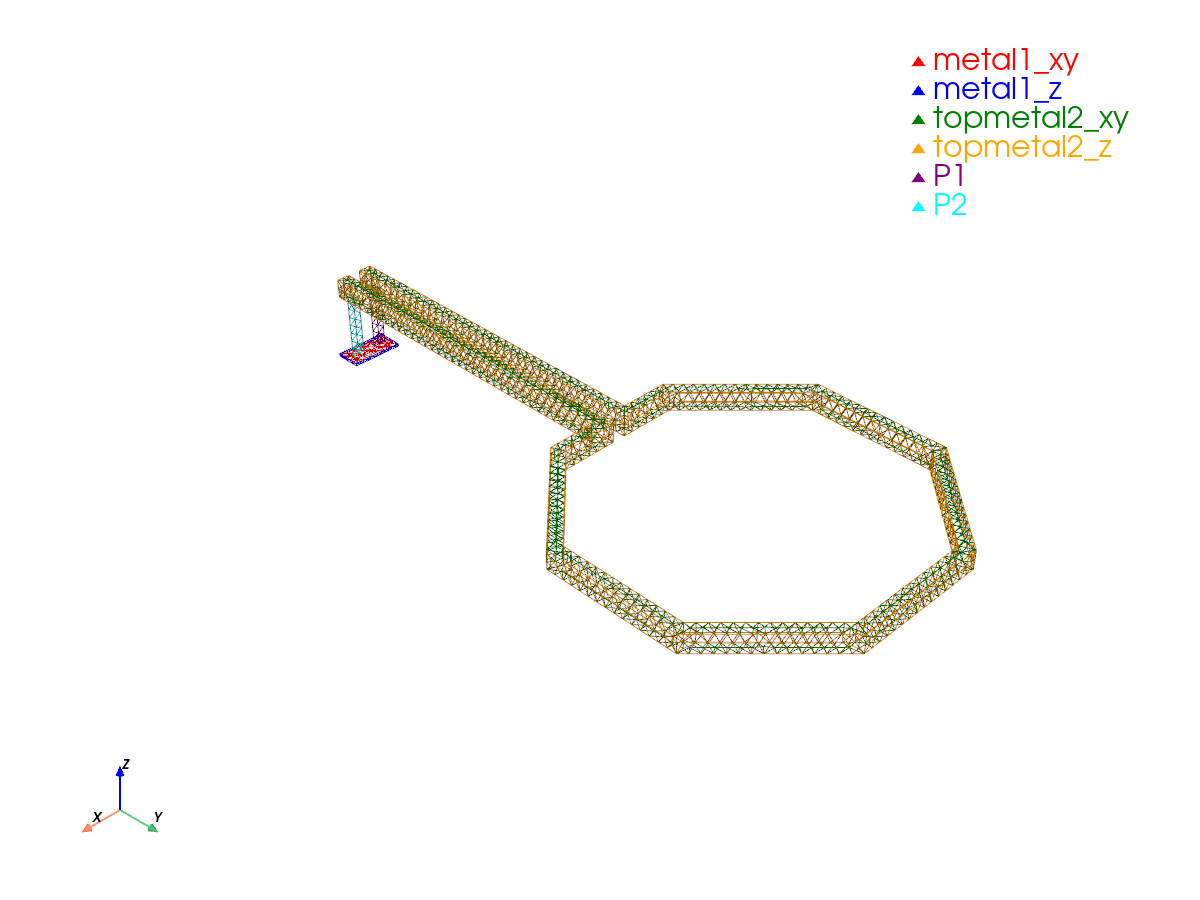

In [5]:
sim.plot_mesh(show_groups=["metal","P"],interactive=False)

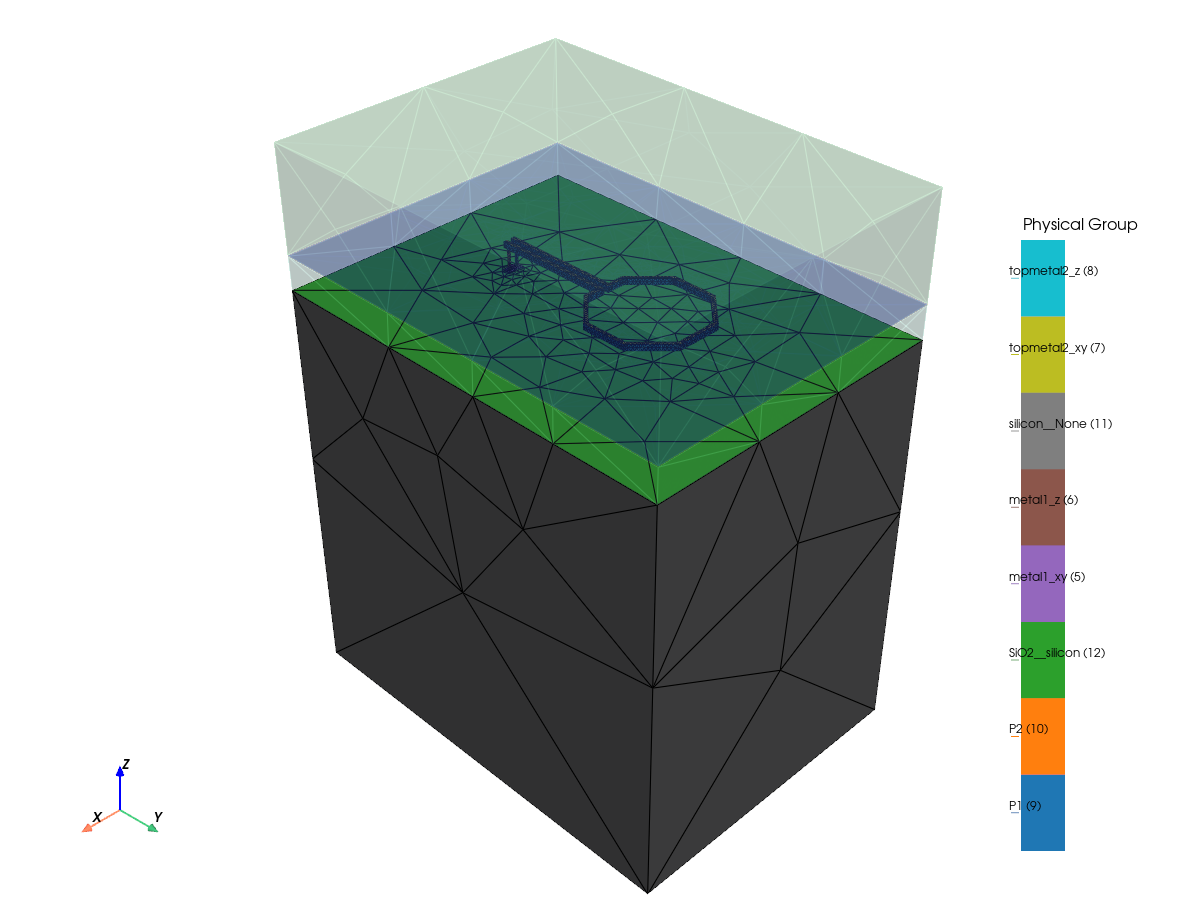

In [6]:
sim.plot_mesh(
    style="solid", interactive=False, 
    transparent_groups=["air__None","air__passive","SiO2__None","SiO2__passive","passive__None"],
)

In [7]:
results = sim.run(parent_dir="runs")

  palace-6b2c3436  completed  0m 46s
Extracting results.tar.gz...
Downloaded 11 files to runs/sim-data-palace-6b2c3436


In [8]:
fig = results.plot_interactive()
fig.update_layout(title="Minimal Metal1 Patches (Port Anchors Only)")
fig.show()

Port mapping: Port 1: P1, Port 2: P2


In [9]:
results.plot_interactive(phase=True)

Port mapping: Port 1: P1, Port 2: P2


In [10]:
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt

Build the Network from raw results 

In [11]:
f = results.freq * 1e9  # GHz → Hz
w = 2 * np.pi * f

ports = results.port_names
n = len(ports)

S = np.zeros((len(f), n, n), dtype=complex)
for i, pi in enumerate(ports):
    for j, pj in enumerate(ports):
        S[:, i, j] = results[(pi, pj)].complex

ntwk = rf.Network(f=f, s=S, f_unit='hz')
Z = ntwk.z
Y = ntwk.y

Single-Ended Extraction (Port 2 Grounded)

In [12]:
Y11 = Y[:, 0, 0]
L_single = np.imag(1 / Y11) / w
Q_single = - np.imag(Y11) / np.real(Y11)

# Mask to find Peak Q only in the inductive region (before SRF)
mask = L_single > 0
idx_se = np.argmax(Q_single[mask])
f_masked_se = f[mask]

print(f"L @ 1 GHz  = {L_single[0]*1e12:.1f} pH")
print(f"Peak Q     = {Q_single[mask][idx_se]:.1f} @ {f_masked_se[idx_se]/1e9:.1f} GHz")

L @ 1 GHz  = 140.1 pH
Peak Q     = 15.8 @ 70.9 GHz


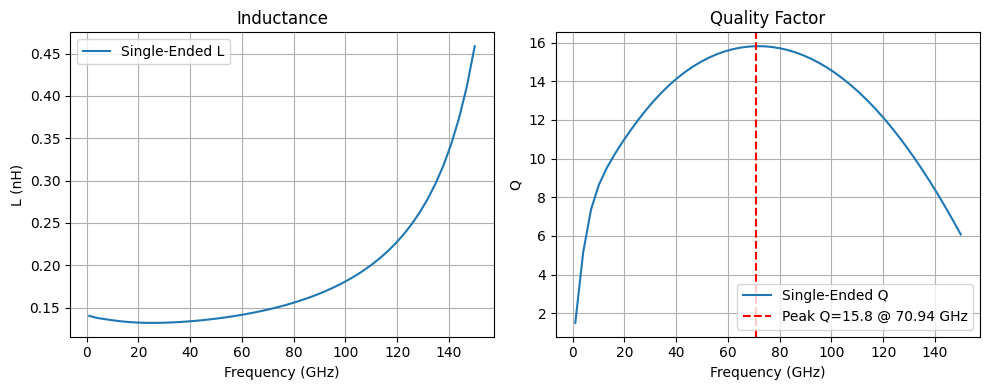

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- Plot 1: Inductance ---
ax1.plot(f / 1e9, L_single * 1e9, label='Single-Ended L')
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("L (nH)")
ax1.set_title("Inductance")
ax1.grid(True)
ax1.legend()

# --- Plot 2: Quality Factor ---
ax2.plot(f/1e9, Q_single, label='Single-Ended Q')
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Q")
ax2.set_title("Quality Factor")
ax2.axvline(f_masked_se[idx_se]/1e9, color='r', linestyle='--', label=f"Peak Q={Q_single[idx_se]:.1f} @ {f_masked_se[idx_se]/1e9:.2f} GHz")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Intrinsic Series Extraction (from Y21)

In [14]:
Y21 = Y[:, 1, 0] # or Y[:, 0, 1] for Y12

# Convert series admittance back to series impedance
# The negative sign is required because Y21 = -Y_series
Z_series = -1 / Y21
Q_series = np.imag(Z_series) / np.real(Z_series)
L_series = np.imag(Z_series) / w

mask = L_series > 0
idx_series = np.argmax(Q_series[mask])
f_masked_series = f[mask]

print(f"L @ 1 GHz  = {L_series[0]*1e12:.1f} pH")
print(f"Peak Q     = {Q_series[mask][idx_series]:.1f} @ {f_masked_series[idx_series]/1e9:.1f} GHz")

L @ 1 GHz  = 140.1 pH
Peak Q     = 16.4 @ 77.0 GHz


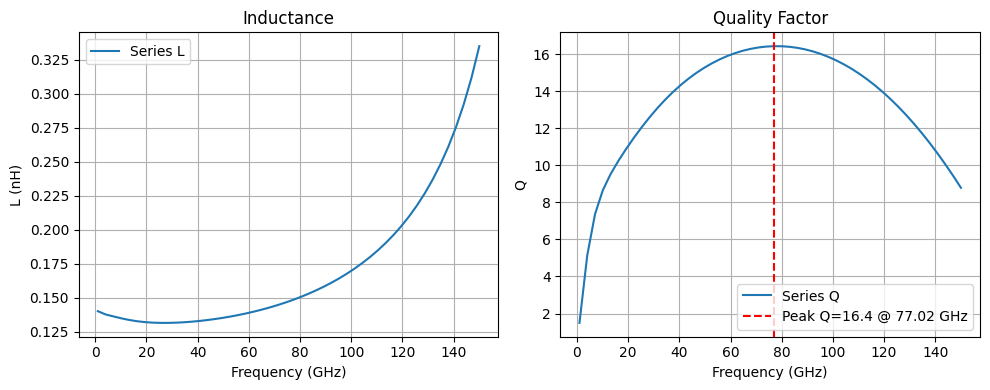

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- Plot 1: Inductance ---
ax1.plot(f / 1e9, L_series * 1e9, label='Series L')
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("L (nH)")
ax1.set_title("Inductance")
ax1.grid(True)
ax1.legend()

# --- Plot 2: Quality Factor ---
ax2.plot(f/1e9, Q_series, label='Series Q')
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Q")
ax2.set_title("Quality Factor")
ax2.axvline(f_masked_series[idx_series]/1e9, color='r', linestyle='--', label=f"Peak Q={Q_series[idx_series]:.1f} @ {f_masked_series[idx_series]/1e9:.2f} GHz")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Differential Extraction (Push-Pull)

In [16]:
Z_diff = Z[:, 0, 0] + Z[:, 1, 1] - Z[:, 0, 1] - Z[:, 1, 0]
L_diff = (np.imag(Z_diff) / w) 
Q_diff = np.imag(Z_diff) / np.real(Z_diff)

mask = L_diff > 0
idx_diff = np.argmax(Q_diff[mask])
f_masked_diff = f[mask]

print(f"L @ 1 GHz  = {L_diff[0]*1e12:.1f} pH")
print(f"Peak Q     = {Q_diff[mask][idx_diff]:.1f} @ {f_masked_diff[idx_diff]/1e9:.1f} GHz")

L @ 1 GHz  = 140.1 pH
Peak Q     = 16.1 @ 74.0 GHz


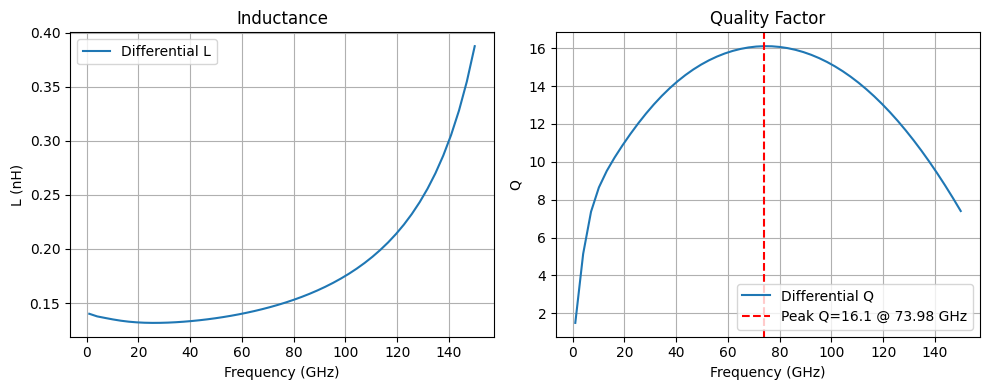

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# --- Plot 1: Inductance ---
ax1.plot(f / 1e9, L_diff * 1e9, label='Differential L')
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("L (nH)")
ax1.set_title("Inductance")
ax1.grid(True)
ax1.legend()

# --- Plot 2: Quality Factor ---
ax2.plot(f/1e9, Q_diff, label='Differential Q')
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("Q")
ax2.set_title("Quality Factor")
ax2.axvline(f_masked_diff[idx_diff]/1e9, color='r', linestyle='--', label=f"Peak Q={Q_diff[mask][idx_diff]:.1f} @ {f_masked_diff[idx_diff]/1e9:.2f} GHz")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()